In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain,
                        proposals, updaters, constraints, accept, Election)

import maup

from gerrychain.proposals import recom, propose_random_flip

from gerrychain.tree import recursive_tree_part, recursive_seed_part

from gerrychain.metrics import efficiency_gap, mean_median, polsby_popper, partisan_bias

from gerrychain.updaters import cut_edges

from gerrychain.tree import bipartition_tree, find_balanced_edge_cuts_memoization


from collections import Counter
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

In [3]:
df = gpd.read_file("../FL_Processed/output/FL_Processed_Precincts_ALARM.shp")

In [ ]:
blocks = gpd.read_file("../FL_Processed/fl_2024_gen_2020_blocks/fl_2024_gen_2020_blocks/fl_2024_gen_2020_blocks.shp")
block_pop = gpd.read_file("../FL_Processed/fl_pl2020_b/fl_pl2020_p2_b.shp")
block_pop_vap = gpd.read_file("../FL_Processed/fl_pl2020_b/fl_pl2020_p4_b.shp")

In [4]:
block_pop['Total'] = block_pop['P0020001']
block_pop['Hispanic'] = block_pop['P0020002']
block_pop['NH_White'] = block_pop['P0020005']
# NH_Black captures all census respondents that indicated Black as any of their race selections
block_pop['NH_Black'] = block_pop['P0020006'] + block_pop['P0020013'] + block_pop['P0020018'] + block_pop['P0020019'] + block_pop['P0020020'] + block_pop['P0020021'] + block_pop['P0020029'] + block_pop['P0020030'] + block_pop['P0020031'] + block_pop['P0020032'] + block_pop['P0020039'] + block_pop['P0020040'] + block_pop['P0020041'] + block_pop['P0020042'] + block_pop['P0020043'] + block_pop['P0020044'] + block_pop['P0020050'] + block_pop['P0020051'] + block_pop['P0020052'] + block_pop['P0020053'] + block_pop['P0020054'] + block_pop['P0020055'] + block_pop['P0020060'] + block_pop['P0020061'] + block_pop['P0020062'] + block_pop['P0020063'] + block_pop['P0020066'] + block_pop['P0020067'] + block_pop['P0020068'] + block_pop['P0020069'] + block_pop['P0020071'] + block_pop['P0020073']
block_pop['NH_Other'] = block_pop['Total'] - block_pop['Hispanic'] - block_pop['NH_White'] - block_pop['NH_Black']

block_pop_vap['Total_VAP'] = block_pop_vap['P0040001']
block_pop_vap['Hispanic_VAP'] = block_pop_vap['P0040002']
block_pop_vap['NH_White_VAP'] = block_pop_vap['P0040005']
# NH_Black captures all census respondents that indicated Black as any of their race selections
block_pop_vap['NH_Black_VAP'] = block_pop_vap['P0040006'] + block_pop_vap['P0040013'] + block_pop_vap['P0040018'] + block_pop_vap['P0040019'] + block_pop_vap['P0040020'] + block_pop_vap['P0040021'] + block_pop_vap['P0040029'] + block_pop_vap['P0040030'] + block_pop_vap['P0040031'] + block_pop_vap['P0040032'] + block_pop_vap['P0040039'] + block_pop_vap['P0040040'] + block_pop_vap['P0040041'] + block_pop_vap['P0040042'] + block_pop_vap['P0040043'] + block_pop_vap['P0040044'] + block_pop_vap['P0040050'] + block_pop_vap['P0040051'] + block_pop_vap['P0040052'] + block_pop_vap['P0040053'] + block_pop_vap['P0040054'] + block_pop_vap['P0040055'] + block_pop_vap['P0040060'] + block_pop_vap['P0040061'] + block_pop_vap['P0040062'] + block_pop_vap['P0040063'] + block_pop_vap['P0040066'] + block_pop_vap['P0040067'] + block_pop_vap['P0040068'] + block_pop_vap['P0040069'] + block_pop_vap['P0040071'] + block_pop_vap['P0040073']
block_pop_vap['NH_Other_VAP'] = block_pop_vap['Total_VAP'] - block_pop_vap['Hispanic_VAP'] - block_pop_vap['NH_White_VAP'] - block_pop_vap['NH_Black_VAP']

blocks_w_pop = blocks.merge(block_pop[['GEOID20','Total','Hispanic','NH_White','NH_Black','NH_Other']].set_index('GEOID20'),on="GEOID20")
blocks_w_pop = blocks_w_pop.merge(block_pop_vap[['GEOID20','Total_VAP','Hispanic_VAP','NH_White_VAP','NH_Black_VAP','NH_Other_VAP']].set_index('GEOID20'),on="GEOID20")

In [ ]:
variables = ["G24PREDHAR", "G24PRERTRU",'G24USSRSCO','G24USSDMUC',
             'Total','Hispanic','NH_White','NH_Black','NH_Other',
             'Total_VAP','Hispanic_VAP','NH_White_VAP','NH_Black_VAP','NH_Other_VAP']

df = df.to_crs(blocks_w_pop.crs)
blocks_to_precincts_assignment = maup.assign(blocks_w_pop, df)

df[variables] = blocks_w_pop[variables].groupby(blocks_to_precincts_assignment).sum()
df = df.fillna(0)

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\intersections.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df = df[df.area > area_cutoff].reset_index(drop=True)
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\intersections.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geometries = geometries[geometries.area > area_cutoff]
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\assign.py:38: UserWarning: Geometry is in a geograp

In [6]:
df['Total'].sum()

10711908.0

In [7]:
df['pop'].sum()

10711908.0

In [8]:
df[df['Total'].isna()]

,GEOID,state,county,muni,cnty_mn,cd_2010,cd_2020,vtd,pop,pop_hsp,...,Total,Hispanic,NH_White,NH_Black,NH_Other,Total_VAP,Hispanic_VAP,NH_White_VAP,NH_Black_VAP,NH_Other_VAP


In [ ]:
graph = Graph.from_geodataframe(df,ignore_errors=True)
df.to_file("./output/FL_Processed_Precincts_ALARM_race.shp")

graph.to_json("./output/FL_Processed_Precincts_ALARM_race.json")

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\gerrychain\graph\graph.py:266: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = df.geometry.area.to_dict()
C:\Users\angel\AppData\Local\Temp\ipykernel_7328\3147126206.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  df.to_file("./output/GA_Processed_Precincts_ALARM_race.shp")


In [ ]:
df = gpd.read_file("./output/FL_Processed_Precincts_ALARM_race.shp")
graph=Graph.from_geodataframe(df,ignore_errors=True)

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\gerrychain\graph\graph.py:266: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = df.geometry.area.to_dict()


C:\Users\angel\AppData\Local\Temp\ipykernel_7328\2401054054.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  smc_plans = pd.read_csv("./ga_alarm_plans.csv")


(-85.84627525000184,
 -80.54184975000167,
 30.125474700823368,
 35.233485300892674)

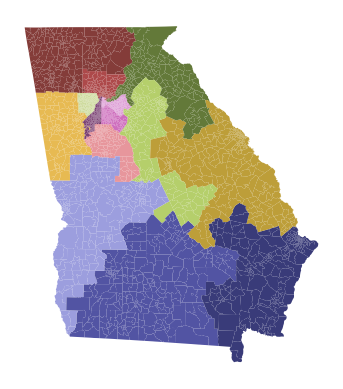

In [ ]:
smc_plans = pd.read_csv("./fl_alarm_plans.csv")

smc_plans.rename(columns={"Unnamed: 0":"GEOID"},inplace=True)

smc_plans["GEOID"] = smc_plans["GEOID"].astype("str")

df = df.merge(smc_plans,on="GEOID")

df.plot(column="V123",cmap="tab20b")
plt.axis('off')

In [ ]:
def count_spanning(graph):
    laplacian = nx.laplacian_matrix(graph)
    L = np.delete(np.delete(laplacian.todense(), 0, 0), 1, 1)
    return np.linalg.slogdet(L)[1]

def county_splits(partition, df=df):
    df["current"] = df.index.map(partition.assignment)

    counties = sum(df.groupby("county")['current'].nunique()>1)
    return counties

election_names = [
    "PRE",
    "USS"
]

num_elections = len(election_names)

election_columns = [
    ["G24PREDHAR", "G24PRERTRU"],
    ['G24USSRSCO','G24USSDMUC']
]

my_updaters = {
    "population": updaters.Tally("pop", alias="population"),
    "cut_edges": cut_edges,
    "PP":polsby_popper,
    "county_splits": county_splits
}

elections = [
    Election(
        election_names[i],
        {"Democratic": election_columns[i][1], "Republican": election_columns[i][0]},
    )
    for i in range(num_elections)
]

election_updaters = {election.name: election for election in elections}
for node in graph.nodes():
    graph.nodes()[node]["non_NH_Black"] = graph.nodes()[node]["Total"] - graph.nodes()[node]["NH_Black"]


my_updaters.update({"NH_Black": Election("NH_Black", {"NH_Black": "NH_Black", "non_NH_Black": "non_NH_Black"})})

# save percentages

my_updaters.update(election_updaters)


In [23]:
cs = [] # county splits
mms = [] # mean median
egs = [] # efficiency gap
pbs = [] # partisan bias
dvp = [] # dem voting perc
pps = [] # polsby popper
bvp = [] # black voting percent
mbvp = [] # max black voting percent
wins = [] # dem wins


for i in range(1,5001): # num of trees to generate
    tree_partition = GeographicPartition(graph, df[f"V{i}"], my_updaters)

    cs.append(tree_partition['county_splits'])
    mms.append(mean_median(tree_partition['PRE']))
    egs.append(efficiency_gap(tree_partition['PRE']))
    pbs.append(partisan_bias(tree_partition['PRE']))
    dvp.append(sorted(tree_partition['PRE'].percents("Democratic")))
    pps.append(sum([1/x for x in polsby_popper(tree_partition).values()])/14)
    bvp.append(sorted(tree_partition['NH_Black'].percents("NH_Black")))
    mbvp.append(max(bvp[-1]))
    wins.append(tree_partition['PRE'].wins("Democratic"))
"""
    if i <= 100:
        #df['current'] = df["GEOID"].map(cd_dict)
        df.plot(column=f'V{i}',cmap='tab20b')
        plt.axis('off')
        plt.savefig(f'./NC_ALARM_Ensemble_graph/df_plot_{i}.png')
        plt.close()

    plt.figure(figsize=(10,4))
    nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[cd_dict[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)
    plt.savefig(f'./NC_First_Ensemble_gif/network_plot_{i}.png')
    plt.close()

    df['current'] = df["PRECINCTID"].map(cd_dict)
    df.plot(column='current',cmap='tab20b')
    plt.axis('off')
    plt.savefig(f'./NC_First_Ensemble_gif/df_plot{i}.png')
    plt.close()
"""


'\n    if i <= 100:\n        #df[\'current\'] = df["GEOID"].map(cd_dict)\n        df.plot(column=f\'V{i}\',cmap=\'tab20b\')\n        plt.axis(\'off\')\n        plt.savefig(f\'./NC_ALARM_Ensemble_graph/df_plot_{i}.png\')\n        plt.close()\n\n    plt.figure(figsize=(10,4))\n    nx.draw(graph, pos={x:(graph.nodes()[x][\'C_X\'], graph.nodes()[x][\'C_Y\']) for x in graph.nodes()}, node_color=[cd_dict[x] for x in graph.nodes()],cmap =\'tab20b\',node_size=15)\n    plt.savefig(f\'./NC_First_Ensemble_gif/network_plot_{i}.png\')\n    plt.close()\n\n    df[\'current\'] = df["PRECINCTID"].map(cd_dict)\n    df.plot(column=\'current\',cmap=\'tab20b\')\n    plt.axis(\'off\')\n    plt.savefig(f\'./NC_First_Ensemble_gif/df_plot{i}.png\')\n    plt.close()\n'

In [ ]:
chain = pd.DataFrame({"cs": cs, "mms":mms,"egs":egs,"pbs":pbs,"pps":pps,"wins":wins})
chain.to_csv('./FL_ALARM_Ensemble_stats/chain_outputs.csv', index=False)

In [ ]:
import csv

with open(f"./FL_ALARM_Ensemble_stats/DemPercs.csv","w") as tf1:
    writer = csv.writer(tf1, lineterminator="\n")
    writer.writerows(dvp)

with open(f"./FL_ALARM_Ensemble_stats/BlackPerc.csv","w") as tf1:
    writer = csv.writer(tf1, lineterminator="\n")
    writer.writerows(bvp)

In [43]:
print(str(df.columns))

Index(['GEOID', 'state', 'county', 'muni', 'cnty_mn', 'cd_2010', 'vtd', 'pop',
       'pop_hsp', 'pop_wht',
       ...
       'V4991', 'V4992', 'V4993', 'V4994', 'V4995', 'V4996', 'V4997', 'V4998',
       'V4999', 'V5000'],
      dtype='object', length=5067)


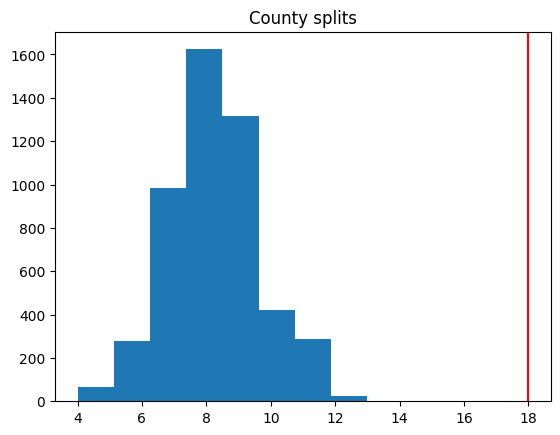

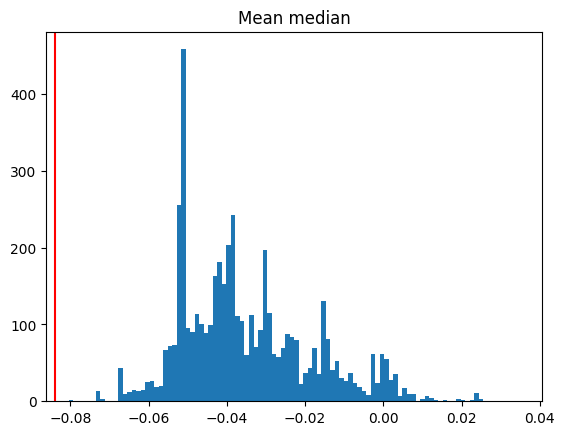

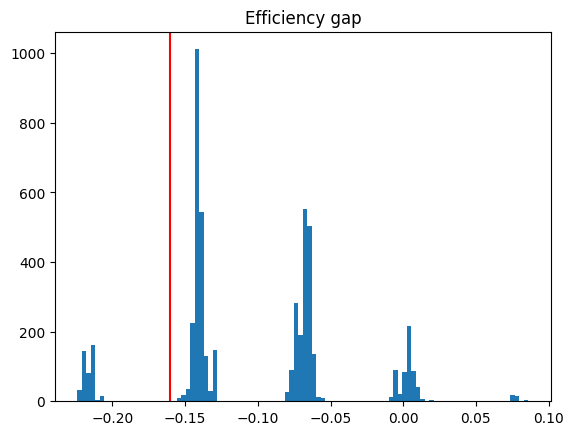

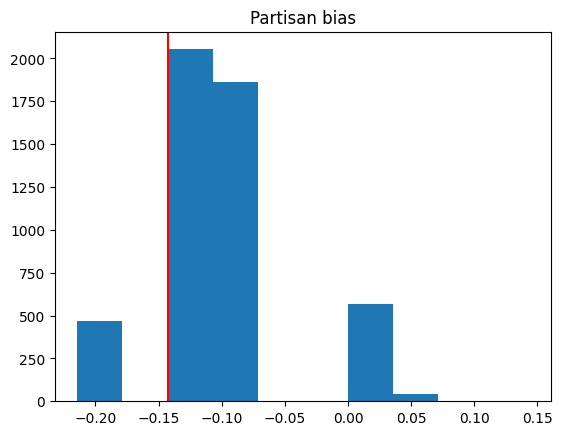

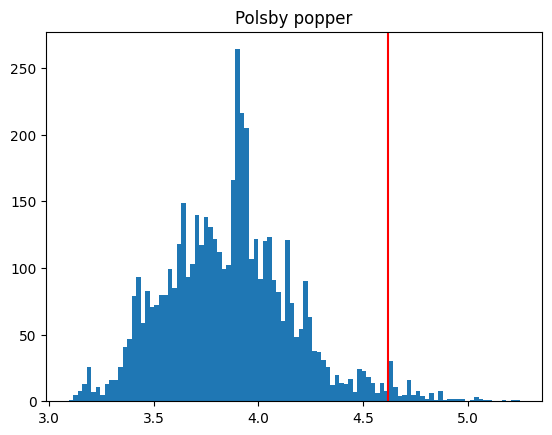

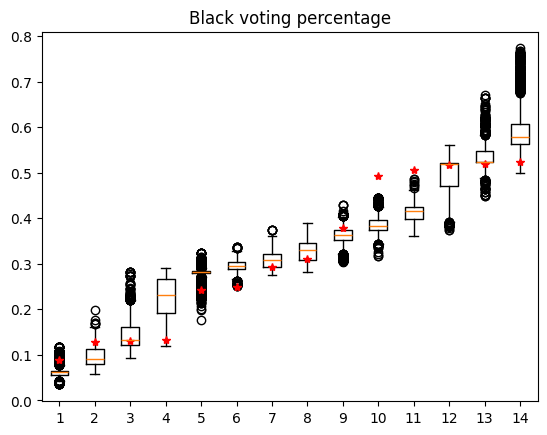

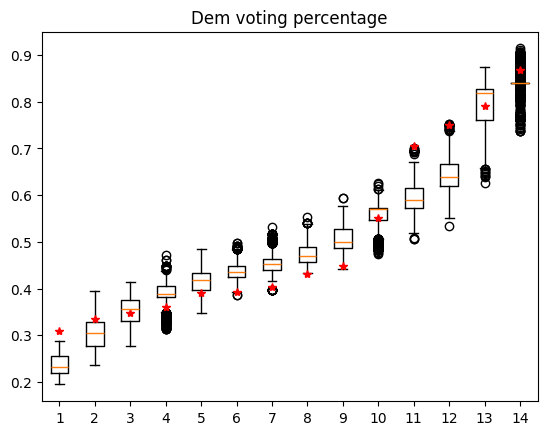

In [ ]:
plt.hist(cs, bins=8)
plt.axvline(23, color='red',label='Enacted')
plt.title("County splits")
plt.show()

plt.hist(mms,bins=100)
plt.axvline(-0.014155299362330176, color='red',label='Enacted')
plt.title("Mean median")
plt.show()

plt.hist(egs,bins=100)
plt.axvline(-0.11954338694905525, color='red',label='Enacted')
plt.title("Efficiency gap")
plt.show()

plt.hist(pbs)
plt.axvline(-0.17857142857142855, color='red',label='Enacted')
plt.title("Partisan bias")
plt.show()

plt.hist(pps,bins=100)
plt.axvline(3.419145068694334, color='red',label='Enacted')
plt.title("Polsby popper")
plt.show()

bvp = np.array(bvp)
plt.boxplot(bvp)
plt.plot(range(1,29),[0.052246082707777114,
 0.0534631501109194,
 0.07051721303389998,
 0.07619685602000714,
 0.08000436528494002,
 0.09028460405727709,
 0.09254902267314917,
 0.09458810405466124,
 0.10201065149572539,
 0.10225279861054236,
 0.1097335912892745,
 0.11090956273855988,
 0.12252493904943104,
 0.12665351275966705,
 0.13053255740188113,
 0.13056694737907332,
 0.13777798817294823,
 0.1405898702701999,
 0.14577600219638392,
 0.15265149199668604,
 0.15608039926909756,
 0.1685273188516151,
 0.24072914254436747,
 0.24529117872806305,
 0.2787695256603949,
 0.3308474116785315,
 0.44284899902753094,
 0.4574614214415844], "*", color='red',label='NH_Black')
plt.title("Black voting percentage")
plt.show()

dvp = np.array(dvp)
plt.boxplot(dvp)
plt.plot(range(1,29),
         [0.3109543064911424,
 0.3472374964720538,
 0.3481464420261432,
 0.3716088631116955,
 0.3914502746076708,
 0.3916021930667062,
 0.39387929093480334,
 0.3988835964216274,
 0.40753140889814315,
 0.4109165244985153,
 0.41144848343406215,
 0.4140134837083189,
 0.4177868676705867,
 0.4180390504725004,
 0.42135540458111603,
 0.42243832595201253,
 0.427296450317553,
 0.42732592723950535,
 0.43268346353285564,
 0.43691280415708,
 0.44066293160140496,
 0.4480718194201004,
 0.4481216435075618,
 0.4561881709113871,
 0.569804437658005,
 0.6223113404697015,
 0.6930471344074398,
 0.6962679756840695],"*", color='red',label='Enacted')
plt.title("Dem voting percentage")
plt.show()